In [24]:
import csv
import pysam
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
bams = {
    "hp_f1": "../data/BEGONIA_2/begonia_2_sup_v5_no_trim_no_filter.bam",
    "ns_f1": "../data/BEGONIA_4/begonia_4_sup_v5_no_trim_no_filter.bam",
    "hp_p2": "../data/CAMELLIA_007/camellia_007_sup_v5_no_trim_no_filter.bam",
    "ns_p2": "../data/CAMELLIA_008/camellia_008_sup_v5_no_trim_no_filter.bam",
    "hp_c1": "../data/CAMELLIA_11/camellia_11_sup_v5_no_trim_no_filter.bam",
    "ns_c1": "../data/CAMELLIA_17/camellia_17_sup_v5_no_trim_no_filter.bam",
}

In [26]:
# parse bams
with open("../results/qc_output.csv", "w", newline="") as csvfile:
    fieldnames = ["sample", "read_name", "read_length", "qs", "st"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()

    for sample_name, bam_path in bams.items():
        with pysam.AlignmentFile(bam_path, "rb", check_sq=False) as bamfile:
            for read in bamfile:
                try:
                    read_length = len(read.query_sequence)
                    qs_tag = read.get_tag("qs")
                    st_tag = read.get_tag("st")

                    writer.writerow({
                        "sample": sample_name,
                        "read_name":read.query_name,
                        "read_length": read_length,
                        "qs": qs_tag,
                        "st": st_tag
                    })
                except KeyError:
                    continue

In [27]:
# connect
con = duckdb.connect()

# query
query = """
SELECT *
FROM read_csv_auto('../results/qc_output.csv')
WHERE qs IS NOT NULL AND st IS NOT NULL
"""

# load into pandas
df = con.execute(query).fetchdf()

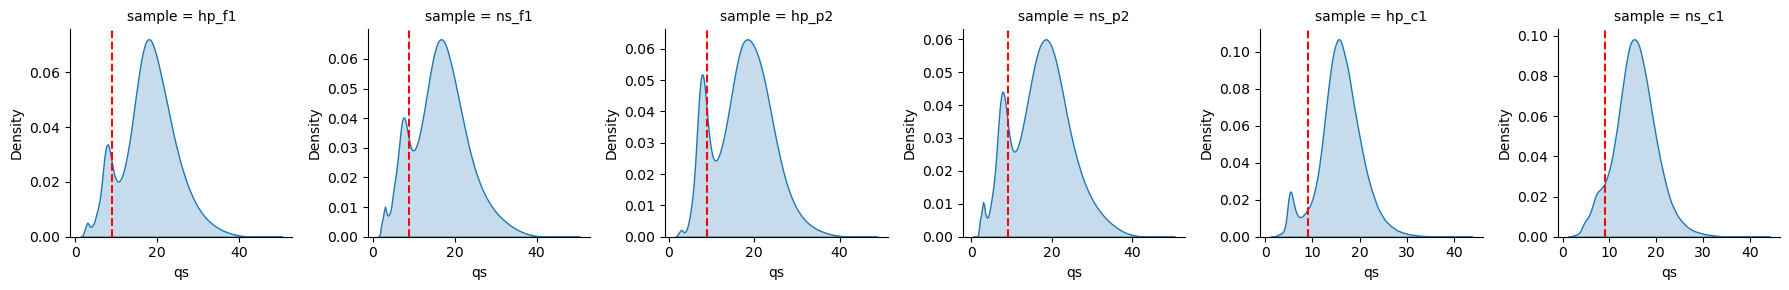

In [28]:
p1 = sns.FacetGrid(df, col="sample", sharex=False, sharey=False)
p1.map(sns.kdeplot, "qs", fill=True)
for ax in p1.axes.flatten():
    ax.axvline(9, color='red', linestyle='--')

plt.show()

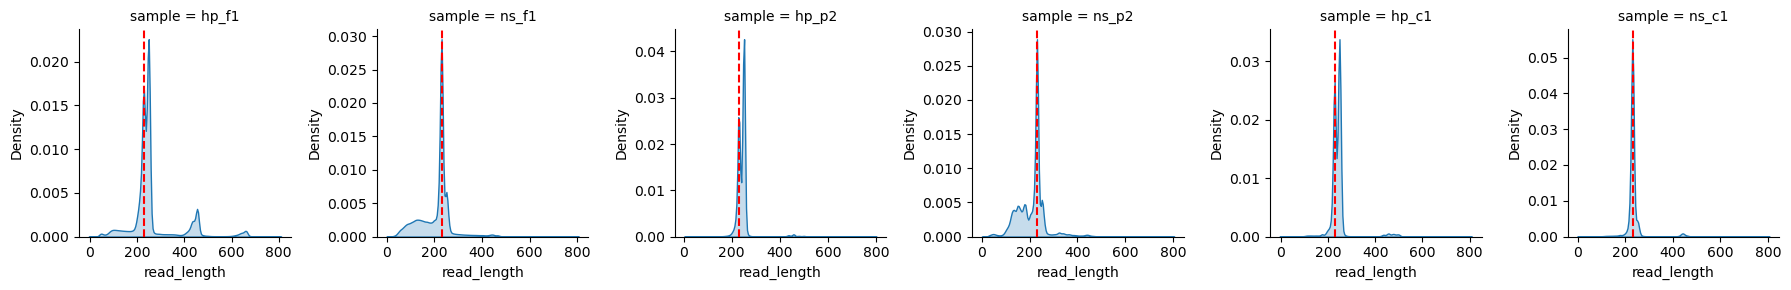

In [29]:
df_len = df[(df["read_length"] <= 800)]

p2 = sns.FacetGrid(df_len, col="sample", sharex=False, sharey=False)
p2.map(sns.kdeplot, "read_length", fill=True)

for ax in p2.axes.flatten():
    ax.axvline(230, color='red', linestyle='--')
    
plt.show()

In [30]:
counts = (
    df.assign(
        st_dt=pd.to_datetime(df['st']),
        st_minute=lambda d: d['st_dt'].dt.floor('min')
    )
    .groupby(['sample', 'st_minute'])
    .size()
    .reset_index(name='count')
    .sort_values(['sample', 'st_minute'])
    .assign(
        cumulative_count=lambda d: d.groupby('sample')['count'].cumsum(),
        minute_offset=lambda d: d.groupby('sample')['st_minute'].transform(
            lambda s: (s - s.min()).dt.total_seconds() / 60.0
        ),
        pool=lambda d: d['sample'].str.split('_').str[1]
    )
)


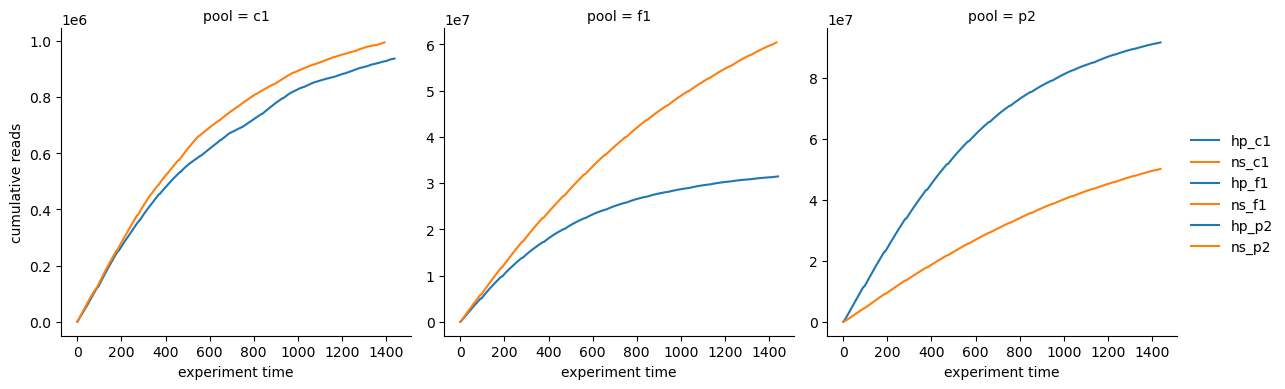

In [31]:
p3=sns.FacetGrid(
    counts,
    col="pool",
    col_wrap=3,
    sharex=True,
    sharey=False,
    height=4
)

p3.map_dataframe(
    sns.lineplot,
    x="minute_offset",
    y="cumulative_count",
    hue="sample"
)

p3.set_axis_labels("experiment time", "cumulative reads")
p3.add_legend()

plt.show()

In [32]:
qced_counts = (
    df
    .query("qs >= 9")
    .groupby("sample")
    .size()
    .reset_index(name="read_count")
    .assign(
        pool=lambda d: d['sample'].str.split('_').str[1],
        prot=lambda d: d['sample'].str.split('_').str[0]
    )
)

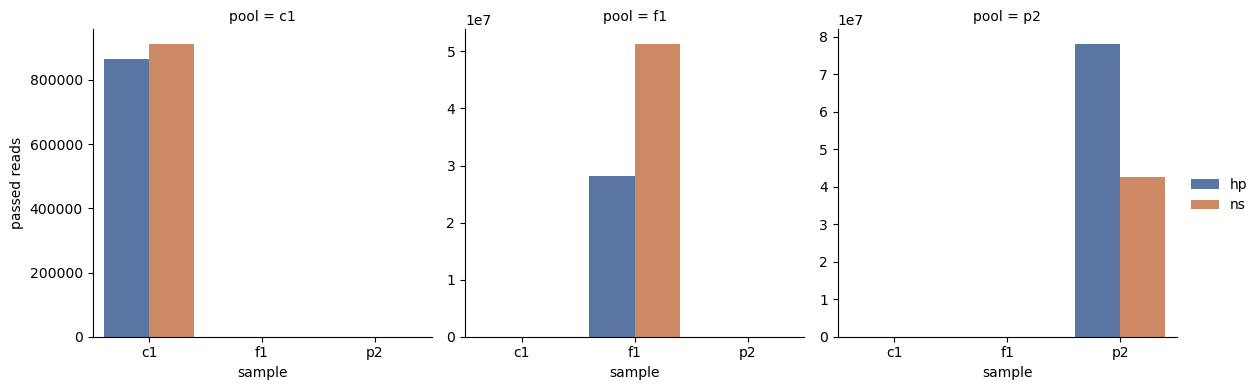

In [34]:
p4=sns.FacetGrid(
    qced_counts,
    col="pool",
    col_wrap=3,
    sharex=True,
    sharey=False,
    height=4
)

p4.map_dataframe(
    sns.barplot,
    x="pool",
    y="read_count",
    hue="prot",
    palette="deep"
)

p4.set_axis_labels("sample", "passed reads")
p4.add_legend()

plt.show()